<h1> Nerual Computing Project </h1>

You are asked to evaluate critically, compare and contrast two NECO methods applied to your choice of data set using Python and Jupyter notebook.

Dataset: UCI ML Repository Dry Bean -  https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

This is a Classification Task. 
* 16 Features
* 7 Labels.

The two Nerual Computing methods I will compare are classification using a Multi Layer Perceptron (MLP) vs a Support Vector Machine (SVM).

In [1]:
# Import Libraries
# Permitted - NumPy, PyTorch, Scikit Learn, Skorch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

<h4> Load Data </h4>

In [3]:
# Import Data from UCI ML REPO
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
dry_bean = fetch_ucirepo(id=602) 

# data (as pandas dataframes) 
X = dry_bean.data.features 
y = dry_bean.data.targets 
  
# metadata 
#print(dry_bean.metadata) 
  
# variable information 
print(dry_bean.variables)

               name     role         type demographic  \
0              Area  Feature      Integer        None   
1         Perimeter  Feature   Continuous        None   
2   MajorAxisLength  Feature   Continuous        None   
3   MinorAxisLength  Feature   Continuous        None   
4       AspectRatio  Feature   Continuous        None   
5      Eccentricity  Feature   Continuous        None   
6        ConvexArea  Feature      Integer        None   
7     EquivDiameter  Feature   Continuous        None   
8            Extent  Feature   Continuous        None   
9          Solidity  Feature   Continuous        None   
10        Roundness  Feature   Continuous        None   
11      Compactness  Feature   Continuous        None   
12     ShapeFactor1  Feature   Continuous        None   
13     ShapeFactor2  Feature   Continuous        None   
14     ShapeFactor3  Feature   Continuous        None   
15     ShapeFactor4  Feature   Continuous        None   
16            Class   Target  C

In [4]:
# Inspect Data Shape
print(X.columns)
print(X.shape)

print(y.columns)
print(y.shape)


Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='object')
(13611, 16)
Index(['Class'], dtype='object')
(13611, 1)


In [5]:
# Check for Missing Data
print('Missing Feature Values: ', X.isna().sum())
print('Missing Target Values: ',y.isna().sum())

Missing Feature Values:  Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
dtype: int64
Missing Target Values:  Class    0
dtype: int64


In [6]:
# Inspect Feature Data
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [7]:
# Feature Data Summary Stats
X.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [8]:
# Target Data Summary Stats
(y.describe())

,Class
count,13611
unique,7
top,DERMASON
freq,3546


In [9]:
# Features Summary Statistics 
X.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [10]:
# Distribution of Target Variable
(y.value_counts(normalize=True))

Class   
DERMASON    0.260525
SIRA        0.193667
SEKER       0.148924
HOROZ       0.141650
CALI        0.119756
BARBUNYA    0.097127
BOMBAY      0.038351
Name: proportion, dtype: float64

<h4> Transform Data </h4>

1. Split → X_train, X_test, y_train, y_test
2. Scale X (fit on X_train, transform all)
3. Split X_train_scaled → X_train_scaled, X_val_scaled (and y_train → y_train, y_val)
4. Encode y (fit on y_train, transform all three)
5. Convert to tensors
6. Wrap in DataLoaders

In [11]:
# Train/Test Split - Stratified Sampling 80 Train 20 Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2, random_state=42, stratify=y
    )
print(y_train.value_counts(normalize=True))

Class   
DERMASON    0.260562
SIRA        0.193699
SEKER       0.148880
HOROZ       0.141624
CALI        0.119765
BARBUNYA    0.097079
BOMBAY      0.038391
Name: proportion, dtype: float64


In [12]:
# Feature Scaling - Z Transform (Normalize) all feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=43, stratify=y_train
)

In [14]:
# Encoding Categorical Variables with IntegerLabel

# Label Encoding (only encode train set)
le = LabelEncoder()

# Fit the encoder on the train data
y_train = le.fit_transform(y_train)

# Apply fitted encoder on the validation and train data
y_val = le.transform(y_val)
y_test = le.transform(y_test)

/Users/joshuabhawanlall/Documents/MSc Data Science/NECO_Proj/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/joshuabhawanlall/Documents/MSc Data Science/NECO_Proj/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Users/joshuabhawanlall/Documents/MSc Data Science/NECO_Proj/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.d

In [15]:
# Convert Data to Tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print('X Train: ', X_train.shape)
print('Y Train: ', y_train.shape)

print('X Validation: ', X_val.shape)
print('Y Validation: ', y_val.shape)

print('X Test: ', X_test.shape)
print('Y Test: ', y_test.shape)

X Train:  torch.Size([8710, 16])
Y Train:  torch.Size([8710])
X Validation:  torch.Size([2178, 16])
Y Validation:  torch.Size([2178])
X Test:  torch.Size([2723, 16])
Y Test:  torch.Size([2723])


In [26]:
# Wrap in Data Loader
batch_size=32

# Training Dataloader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

# Validation DataLoader
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size, shuffle=True)

# Test DataLoader
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset)

<h4> MLP Structure and Hyperparameter Selection </h4>

* <b> Input Layer </b> : 16 Features
* <b> Output Later </b>: 7 possible Classes
* <b> Hidden Layers </b>: 1-2
* <b> Hidden Neurons </b>: 64, 128 (Based on Group Work)
* <b> Activation Function </b>: ReLU (Hidden Layers), Softmax (Output)
* <b> Loss </b>: Cross Entropy Loss

<h4> Structure of Implementation </h4>

* Stage 1: Single layer [128], SGD, no momentum, no weight decay → baseline
* Stage 2: Add momentum=0.9 → does it help?
* Stage 3: Try [128,64] and [128,128] architectures
* Stage 4: Add weight decay → does regularisation help?
* Stage 5: Best MLP config → compare against SVM


Grid Search with Cross Validation (i.e 5 Fold)


<h4>Baseline Model </h4>

* The baseline model uses the assumptions developed based on intial investication (group coursework)
* 1 Hidden Layer, Hidden Layer Dimension = 128, Learning Rate = 0.1. No Momentum, No Weight Decay. 300 Epochs.

In [ ]:
# Build the Model
class Classifier(nn.Module):
    def __init__(self,input_dim,hidden_dim,output_dim): # Structure of the NN
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self,x): # Forward Pass
        x = self.hidden(x)
        x = self.act(x)
        x = self.output(x)
        return x

In [ ]:
#Function for model instantiation
def build_model_and_optimizer(input_dim,hidden_dim,output_dim,lr,momentum,weight_decay):  
    
    # Instantiation of model
    model = Classifier(input_dim,hidden_dim,output_dim) 

    # Loss Function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = optim.SGD(
        model.parameters(),
        lr = lr,
        momentum = momentum,
        weight_decay = weight_decay
    )
    return model, criterion, optimizer

Epoch 25 | Average Train Loss per Batch = 0.1777 | Val Loss: 0.2160 | Acc: 0.9252
Epoch 50 | Average Train Loss per Batch = 0.1684 | Val Loss: 0.2089 | Acc: 0.9270
Epoch 75 | Average Train Loss per Batch = 0.1629 | Val Loss: 0.2050 | Acc: 0.9256
Epoch 100 | Average Train Loss per Batch = 0.1592 | Val Loss: 0.2009 | Acc: 0.9265
Epoch 125 | Average Train Loss per Batch = 0.1555 | Val Loss: 0.1992 | Acc: 0.9284
Epoch 150 | Average Train Loss per Batch = 0.1528 | Val Loss: 0.2092 | Acc: 0.9252
Epoch 175 | Average Train Loss per Batch = 0.1508 | Val Loss: 0.1963 | Acc: 0.9279
Epoch 200 | Average Train Loss per Batch = 0.1481 | Val Loss: 0.2182 | Acc: 0.9178
Epoch 225 | Average Train Loss per Batch = 0.1474 | Val Loss: 0.2212 | Acc: 0.9201
Epoch 250 | Average Train Loss per Batch = 0.1438 | Val Loss: 0.2028 | Acc: 0.9284
Epoch 275 | Average Train Loss per Batch = 0.1416 | Val Loss: 0.2076 | Acc: 0.9252
Epoch 300 | Average Train Loss per Batch = 0.1413 | Val Loss: 0.2180 | Acc: 0.9224

 Test 

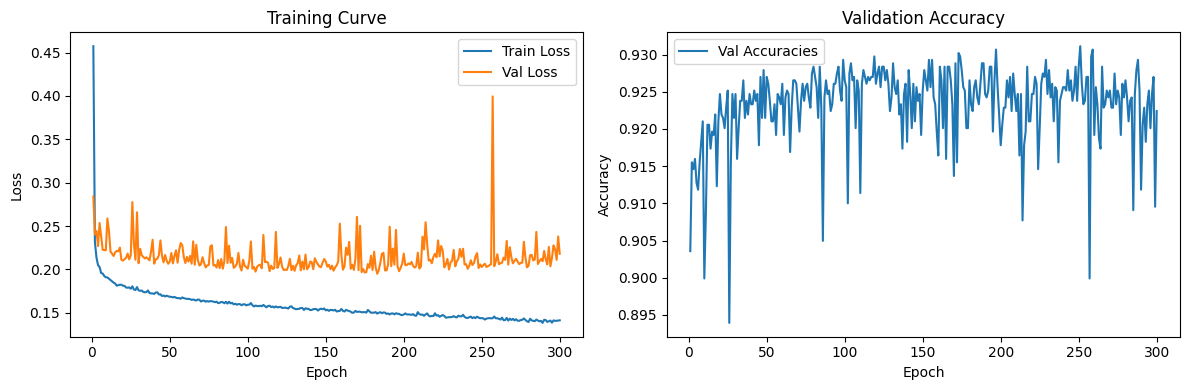

In [41]:
# Baseline Model

# Parameters
input_dim = 16
hidden_dim = 128
output_dim = 7
lr = 0.1
momentum = 0.0
weight_decay = 0.0

# Initialize Model & Opitimizer
model, criterion, optimizer = build_model_and_optimizer(input_dim,hidden_dim,output_dim,lr,momentum,weight_decay)

# Training Loop
num_epochs = 300

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss=0
    for X_batch, y_batch in train_loader:
        # Forward Pass
        outputs = model(X_batch)
        # Calculate Loss
        loss = criterion(outputs, y_batch)
        # Backwards pass (compute gradients)
        optimizer.zero_grad()
        loss.backward()
        # Update parameters (Model Weights)
        optimizer.step()
        train_loss += loss.item() #train loss accumulates per batch
    
    avg_train_loss = train_loss/len(train_loader) #average train loss per batch for epoch

    # Model Evaluation
    model.eval() #switch model to eval
    correct, total, val_loss = 0,0,0
    with torch.no_grad(): # disables gradient computation
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item() # CEL calculates average loss per batch, .item converts to py float
            predicted = torch.argmax(outputs, dim=1) # argmax returns index of highest value, for each row dim=1 find argmax col
            correct += (predicted == y_batch).sum().item() 
            total += y_batch.size(0)

    avg_val_loss = val_loss/len(val_loader)

    if ((epoch+1)%25 ==0):
        #print(f"Epoch {epoch+1}/{num_epochs}, Loss={loss.item():.4f}")
        print(f"Epoch {epoch+1} | Average Train Loss per Batch = {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {correct/total:.4f}")

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(correct/total)


# Test Model Evaluation
model.eval()
correct, total, test_loss = 0,0,0
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        test_loss += criterion(outputs, y_batch).item()
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        all_preds.extend(predicted.numpy())
        all_targets.extend(y_batch.numpy())

avg_test_loss = test_loss/len(test_loader)
accuracy = correct/total

print('\n',f'Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}')

print('\n',classification_report(all_targets, all_preds, target_names=le.classes_))

#Plots
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 4))

#Loss Curve
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()

#Accuracy Curve
plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, label='Val Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

<h4> Randomized Hyperparameter Search </h4>

In [ ]:
# Using Skorch to wrap Pytorch Model so its compatible with RandomziedSearchCV

In [3]:
# Random Search

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Define Parameter Grid

param_dist = {
    'hidden_layer_sizes' : [],
    'activation': [],
    'learning_rate_init': [],
    'alpha': [],
    'batch_size': []
    }